# Paper-1 — Figure generation (English, paper-wise)

Genera las **16 figuras** del paper. Las celdas son **copia literal** de tus notebooks
originales (`tecnicas/ETTh2_tokenization.ipynb`, `notebooks/pipeline_RITMO_etth2.ipynb`,
`notebooks/visualizations.ipynb`); solo traduzco strings ES→EN y ajusto datos a TOP
(3 seeds para downstream, K óptimo robusto para Weather).

**Outputs**: `memoria/secciones/figures_paper1/figXX_*.{png,pdf,svg}`.

In [1]:
# === SETUP — copiado de ETTh2_tokenization.ipynb cell 1 ===
import os, sys, re
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import pickle
from scipy import stats

REPO = Path('/home/jaime/TFG/RITMO')
if Path.cwd() != REPO: os.chdir(REPO)
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))

from tecnicas import (
    sax_discretize, visualize_sax,
    text_based_tokenize, visualize_text_based,
    patching_tokenize, visualize_patches,
    decomposition_tokenize, visualize_decomposition,
    foundation_tokenize, visualize_foundation
)

# CONFIGURACIÓN MATPLOTLIB (idéntica a tus NBs)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 12

plt.rcParams['lines.linewidth'] = 1.0
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.3

sns.set_style('whitegrid')

okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
sns.set_palette(okabe_ito)
colors_oi = okabe_ito  # alias usado en otros NBs

FIGSIZE_SINGLE = (3.5, 2.625)
FIGSIZE_DOUBLE = (7.16, 5.37)

# OUTPUT
OUT_DIR = REPO / 'memoria/secciones/figures_paper1'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig_all(fig, name):
    for ext in ('png', 'pdf', 'svg'):
        fig.savefig(OUT_DIR / f'{name}.{ext}', dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  saved: {name}.{{png,pdf,svg}}')

# Reproducibilidad
import random
random.seed(42); np.random.seed(42); torch.manual_seed(42)

print('[OK] Imports completados')
print(f'  output: {OUT_DIR}')

[OK] Imports completados
  output: /home/jaime/TFG/RITMO/memoria/secciones/figures_paper1


In [2]:
# === DATA LOAD — copiado de ETTh2_tokenization.ipynb cells 2-7 ===
BASE_DIR = REPO
DATASET_DIR = BASE_DIR / 'dataset'
CACHE_DIR = BASE_DIR / 'cache'

# HMM cache ETTh2 K=5 (illustrative)
K_SELECTED = 5
cache_path = CACHE_DIR / f'hmm_etth2_K{K_SELECTED}.pth'
hmm_cache = torch.load(cache_path, weights_only=False)
print(f'[CACHE HMM ETTh2] K={K_SELECTED}, converged={hmm_cache["converged"]}, iters={hmm_cache["n_iter"]}')

# Dataset ETTh2 + RevIN per-window (idéntico al pipeline)
df_etth2 = pd.read_csv(DATASET_DIR / 'ETT-small' / 'ETTh2.csv')
data_raw = df_etth2['OT'].values
n_train = int(len(data_raw) * 0.7)
train_raw = data_raw[:n_train]
SEQ_LEN = 96
windows = []
for start in range(0, len(train_raw) - SEQ_LEN + 1, SEQ_LEN):
    w = train_raw[start:start + SEQ_LEN]
    w_mean, w_std = w.mean(), max(w.std(), 1e-5)
    windows.append((w - w_mean) / w_std)
train_norm = np.concatenate(windows)
print(f'[ETTh2 norm] T={len(train_norm)}, mean={train_norm.mean():.6f}, std={train_norm.std():.6f}')

# Viterbi states
from hmm.viterbi import viterbi_decode
params_np = {
    'A': hmm_cache['A'].numpy(),
    'pi': hmm_cache['pi'].numpy(),
    'mu': hmm_cache['mu'].numpy(),
    'sigma': hmm_cache['sigma'].numpy(),
}
states, log_prob = viterbi_decode(train_norm, params_np['A'], params_np['pi'],
                                   params_np['mu'], params_np['sigma'])

# Estructura compatible
hmm_etth2 = {
    'K': K_SELECTED,
    'data_norm': train_norm,
    'states': states,
    'params': params_np,
}

# Subset visualización
N_TIMESTEPS = 1500
etth2_data_norm = hmm_etth2['data_norm']
etth2_states = hmm_etth2['states']
etth2_params = hmm_etth2['params']
etth2_series = etth2_data_norm[:N_TIMESTEPS]
etth2_states_vis = etth2_states[:N_TIMESTEPS]

# Aplicar 5 técnicas
etth2_sax = sax_discretize(etth2_series, alphabet_size=8)
etth2_text = text_based_tokenize(etth2_series, base=10, precision=2)
etth2_patch_array = patching_tokenize(etth2_series, patch_len=16, stride=16)
etth2_patch = visualize_patches(etth2_series, etth2_patch_array, 16, 16)
etth2_decomp = decomposition_tokenize(etth2_series, kernel_size=25)
etth2_foundation = foundation_tokenize(etth2_series, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)

print(f'[OK] Tokenizers applied to ETTh2 (T={N_TIMESTEPS} timesteps)')

[CACHE HMM ETTh2] K=5, converged=True, iters=231
[ETTh2 norm] T=12192, mean=0.000000, std=1.000000
[OK] Tokenizers applied to ETTh2 (T=1500 timesteps)


  saved: fig02_revin_etth2_normalized.{png,pdf,svg}


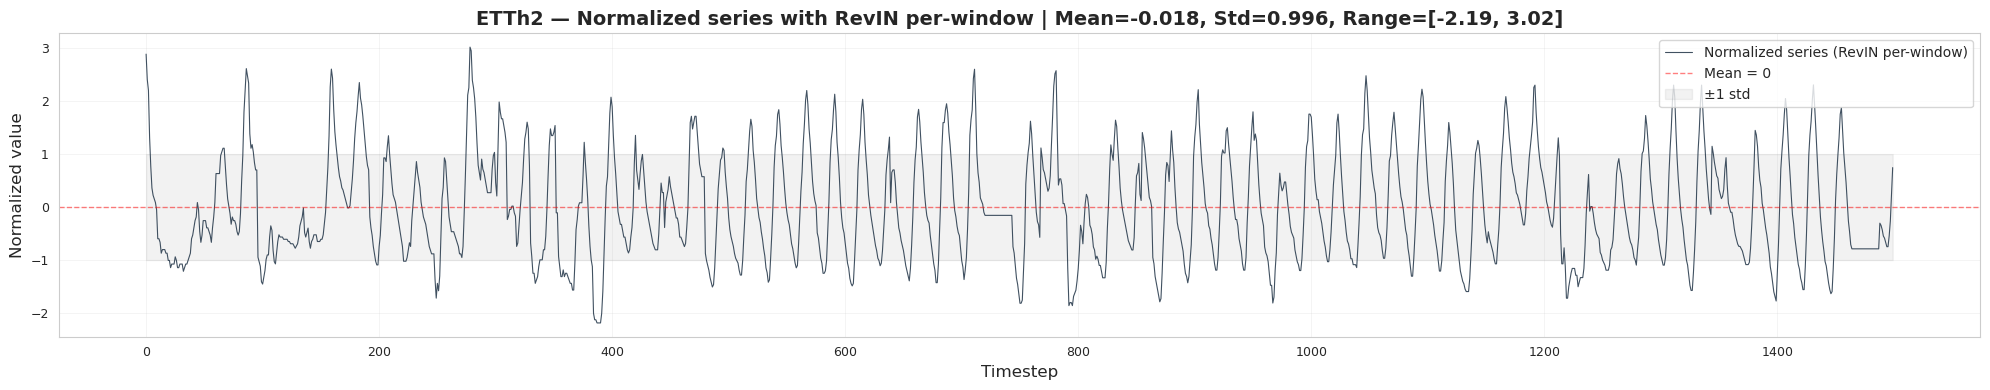

In [3]:
# === FIGURE 2 — RevIN-normalized ETTh2 (copia de ETTh2_tokenization cell 9) ===
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(etth2_series, linewidth=0.8, color='#2C3E50', alpha=0.9, label='Normalized series (RevIN per-window)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Mean = 0')
ax.fill_between(range(len(etth2_series)), -1, 1, alpha=0.1, color='gray', label='±1 std')

mean_val = etth2_series.mean()
std_val = etth2_series.std()
min_val = etth2_series.min()
max_val = etth2_series.max()

ax.set_title(f'ETTh2 — Normalized series with RevIN per-window | Mean={mean_val:.3f}, Std={std_val:.3f}, Range=[{min_val:.2f}, {max_val:.2f}]',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Normalized value', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig_all(fig, 'fig02_revin_etth2_normalized')
plt.show()

  saved: fig08_hmm_etth2_K5.{png,pdf,svg}


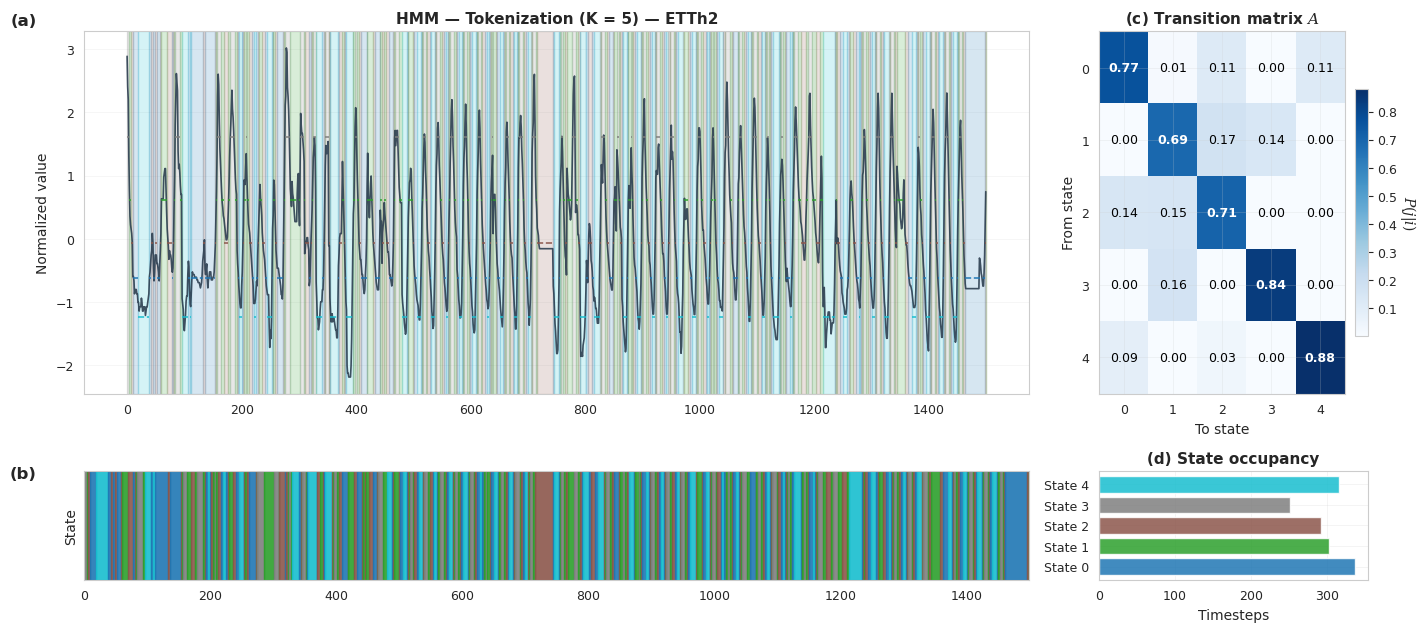

In [4]:
# === FIGURE 8 — HMM K=5 on ETTh2 (copia de ETTh2_tokenization cell 10) ===
fig = plt.figure(figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.6))
gs = fig.add_gridspec(3, 4, height_ratios=[2, 0.6, 1])
ax_series = fig.add_subplot(gs[0, :3])
ax_statebar = fig.add_subplot(gs[1, :3])
ax_trans = fig.add_subplot(gs[0, 3])
ax_occup = fig.add_subplot(gs[1, 3])

ax_series.plot(etth2_series, linewidth=1.2, color='#2C3E50', alpha=0.9, label='Series')
ax_series.set_title(f'HMM — Tokenization (K = {K_SELECTED}) — ETTh2', fontsize=11, fontweight='bold')
ax_series.set_ylabel('Normalized value')
ax_series.grid(True, alpha=0.25)
ax_series.text(-0.05, 1.05, '(a)', transform=ax_series.transAxes,
               fontsize=12, fontweight='bold', va='top', ha='right')

# Contiguous segments
segments = []
if len(etth2_states_vis) > 0:
    start = 0
    curr = int(etth2_states_vis[0])
    for i, s in enumerate(etth2_states_vis):
        s = int(s)
        if s != curr:
            segments.append((start, i, curr))
            start = i; curr = s
    segments.append((start, len(etth2_states_vis), curr))

colors = plt.get_cmap('tab10')(np.linspace(0, 1, max(K_SELECTED, 1)))

for (s, e, state) in segments:
    c = colors[state % len(colors)]
    ax_series.axvspan(s, e, color=c, alpha=0.18)
    mu_k = etth2_params.get('mu', [np.nan]*K_SELECTED)[state]
    ax_series.hlines(mu_k, s, e, colors=[c], linestyles='--', linewidth=1.2, alpha=0.9)

for (s, e, state) in segments:
    c = colors[state % len(colors)]
    ax_statebar.axvspan(s, e, color=c, alpha=0.9)
ax_statebar.set_yticks([])
ax_statebar.set_ylabel('State')
ax_statebar.set_xlim(0, len(etth2_series))
ax_statebar.grid(False)
ax_statebar.text(-0.05, 1.05, '(b)', transform=ax_statebar.transAxes,
                 fontsize=12, fontweight='bold', va='top', ha='right')

A = etth2_params.get('A', None)
if A is not None:
    im = ax_trans.imshow(np.array(A), aspect='auto', cmap='Blues')
    ax_trans.set_title('(c) Transition matrix $A$', fontsize=11, fontweight='bold')
    ax_trans.set_xlabel('To state')
    ax_trans.set_ylabel('From state')
    cbar = plt.colorbar(im, ax=ax_trans, fraction=0.046, pad=0.04)
    cbar.set_label('$P(j|i)$', rotation=270, labelpad=15)

    for i in range(K_SELECTED):
        for j in range(K_SELECTED):
            text_color = 'white' if A[i,j] > 0.5 else 'black'
            ax_trans.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center',
                        color=text_color, fontsize=9, fontweight='bold' if i==j else 'normal')

state_counts = [(etth2_states_vis==k).sum() for k in range(K_SELECTED)]
ax_occup.barh(range(K_SELECTED), state_counts, color=colors[:K_SELECTED], alpha=0.85)
ax_occup.set_yticks(range(K_SELECTED))
ax_occup.set_yticklabels([f'State {k}' for k in range(K_SELECTED)])
ax_occup.set_xlabel('Timesteps')
ax_occup.set_title('(d) State occupancy', fontsize=11, fontweight='bold')

plt.tight_layout()
savefig_all(fig, 'fig08_hmm_etth2_K5')
plt.show()

  saved: fig03_sax_etth2.{png,pdf,svg}


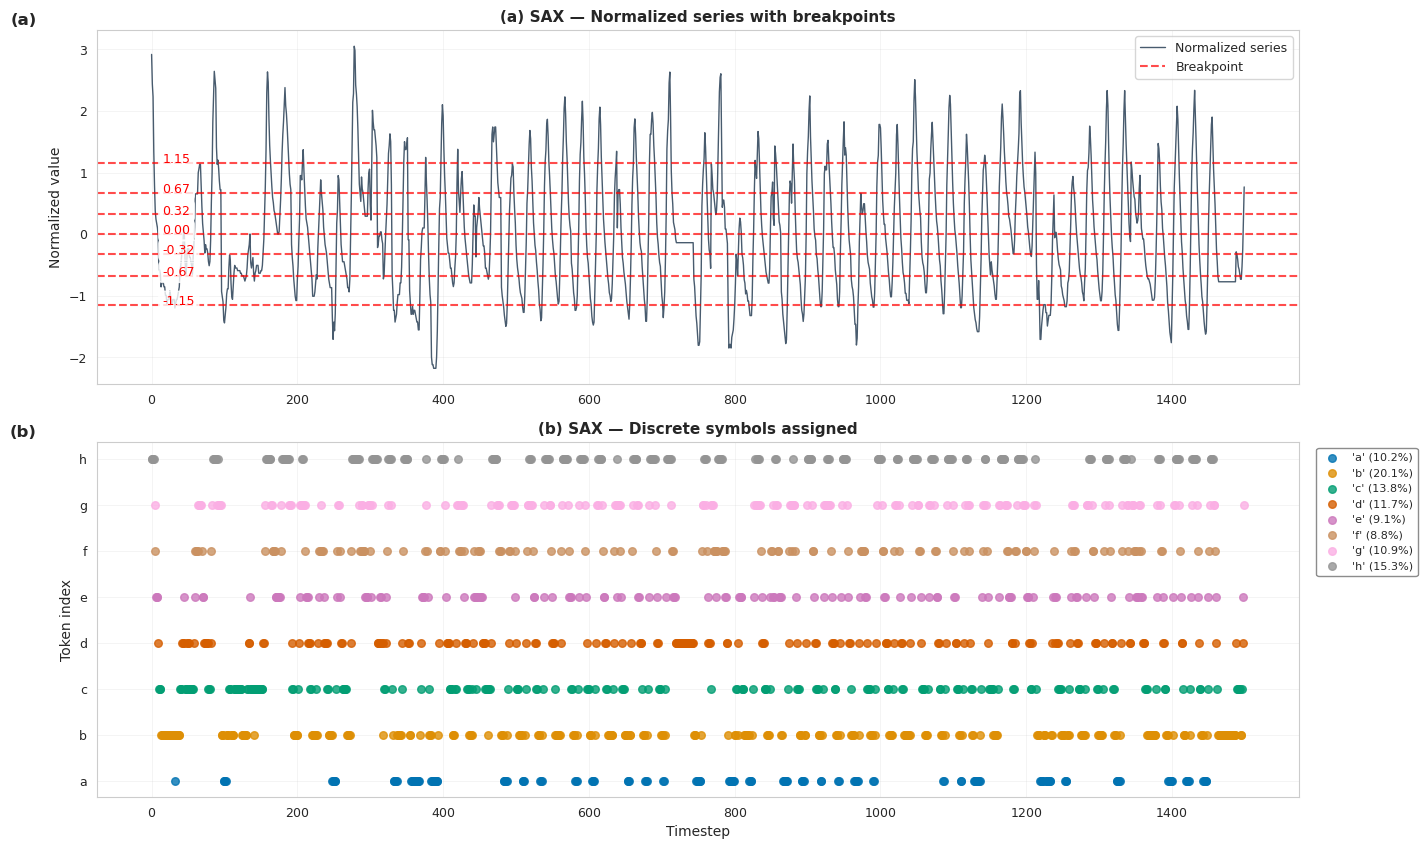

In [5]:
# === FIGURE 3 — SAX on ETTh2 (copia de ETTh2_tokenization cell 11) ===
sax_viz = visualize_sax(etth2_series, etth2_sax['symbols'], etth2_sax['tokens'], etth2_sax['breakpoints'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.6))

ax1.plot(sax_viz['normalized'], linewidth=1, color='#34495E', alpha=0.9, label='Normalized series')
for i, bp in enumerate(etth2_sax['breakpoints']):
    ax1.axhline(bp, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Breakpoint' if i == 0 else '')
    ax1.text(len(etth2_series)*0.01, bp, f'{bp:.2f}', fontsize=9, color='red',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_title('(a) SAX — Normalized series with breakpoints', fontsize=11, fontweight='bold')
ax1.set_ylabel('Normalized value', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

colors_sax = sns.color_palette('colorblind', n_colors=etth2_sax['vocabulary_size'])
for sym_idx in range(etth2_sax['vocabulary_size']):
    mask = etth2_sax['tokens'] == sym_idx
    if mask.any():
        count = mask.sum()
        pct = count / len(etth2_series) * 100
        ax2.scatter(np.where(mask)[0], etth2_sax['tokens'][mask], color=colors_sax[sym_idx],
                    s=30, alpha=0.8, label=f"'{etth2_sax['alphabet'][sym_idx]}' ({pct:.1f}%)")

ax2.set_title('(b) SAX — Discrete symbols assigned', fontsize=11, fontweight='bold')
ax2.set_ylabel('Token index', fontsize=10)
ax2.set_xlabel('Timestep', fontsize=10)
ax2.set_yticks(range(etth2_sax['vocabulary_size']))
ax2.set_yticklabels([etth2_sax['alphabet'][i] for i in range(etth2_sax['vocabulary_size'])])
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), ncol=1, fontsize=8, framealpha=0.9, edgecolor='gray')
ax2.grid(True, alpha=0.3)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
savefig_all(fig, 'fig03_sax_etth2')
plt.show()

  saved: fig04_llmtime_etth2.{png,pdf,svg}


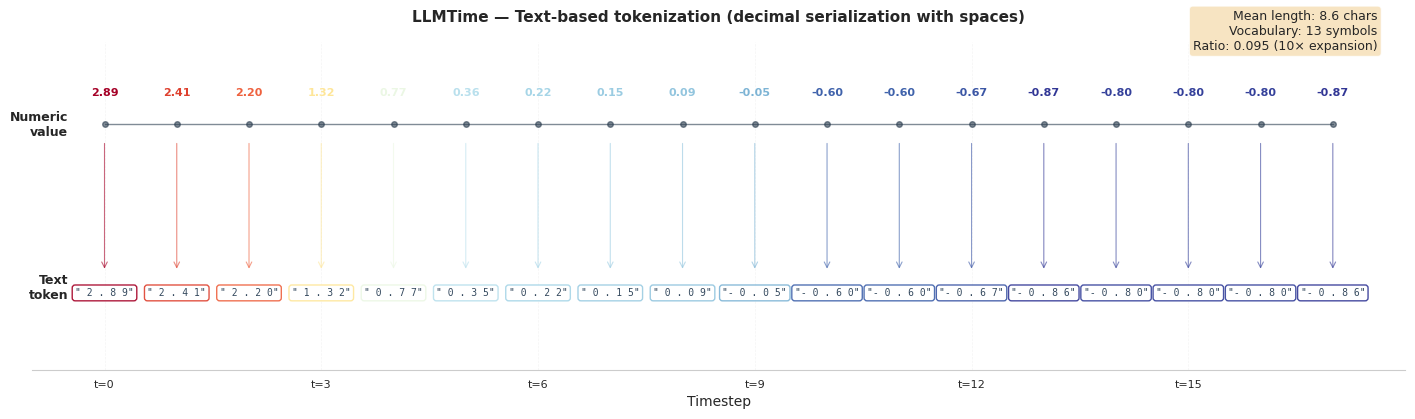

In [6]:
# === FIGURE 4 — LLMTime text-based on ETTh2 (copia de ETTh2_tokenization cell 12) ===
text_viz = visualize_text_based(etth2_series, etth2_text['tokens_per_value'])

N_EXAMPLES = 18
example_values = etth2_series[:N_EXAMPLES]
example_tokens = etth2_text.get('tokens_per_value', [])[:N_EXAMPLES]

fig = plt.figure(figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*0.8))
ax = fig.add_subplot(111)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)

y_series = 0.75
x_positions = np.arange(N_EXAMPLES)
ax.plot(x_positions, [y_series]*N_EXAMPLES, 'o-', color='#2C3E50', markersize=4, linewidth=1, alpha=0.6)

norm_vals = (example_values - example_values.min()) / (example_values.max() - example_values.min() + 1e-8)
colors_map = plt.cm.RdYlBu_r(norm_vals)

y_token = 0.25
for i, (val, token) in enumerate(zip(example_values, example_tokens)):
    ax.text(i, y_series + 0.08, f'{val:.2f}', ha='center', va='bottom',
            fontsize=8, color=colors_map[i], fontweight='bold')
    ax.annotate('', xy=(i, y_token + 0.05), xytext=(i, y_series - 0.05),
                arrowprops=dict(arrowstyle='->', color=colors_map[i], lw=0.8, alpha=0.6))
    ax.text(i, y_token, f'"{token}"', ha='center', va='top',
            fontsize=7, family='monospace', color='#34495E',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=colors_map[i], alpha=0.9))

ax.text(-0.5, y_series, 'Numeric\nvalue', ha='right', va='center', fontsize=9, fontweight='bold')
ax.text(-0.5, y_token, 'Text\ntoken', ha='right', va='center', fontsize=9, fontweight='bold')

avg_len = text_viz.get('avg_token_length', 0)
vocab_size = etth2_text.get('vocabulary_size', 0)
comp_ratio = etth2_text.get('compression_ratio', 0)
metrics_text = (f'Mean length: {avg_len:.1f} chars\n'
                f'Vocabulary: {vocab_size} symbols\n'
                f'Ratio: {comp_ratio:.3f} (10× expansion)')
ax.text(0.98, 1.1, metrics_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title('LLMTime — Text-based tokenization (decimal serialization with spaces)',
             fontsize=11, fontweight='bold', pad=15)
ax.set_xlim(-1, N_EXAMPLES)
ax.set_ylim(0, 1)
ax.set_xticks(x_positions[::3])
ax.set_xticklabels([f't={i}' for i in x_positions[::3]], fontsize=8)
ax.set_yticks([])
ax.set_xlabel('Timestep', fontsize=10)
ax.grid(True, axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
savefig_all(fig, 'fig04_llmtime_etth2')
plt.show()

  saved: fig05_patchtst_etth2.{png,pdf,svg}


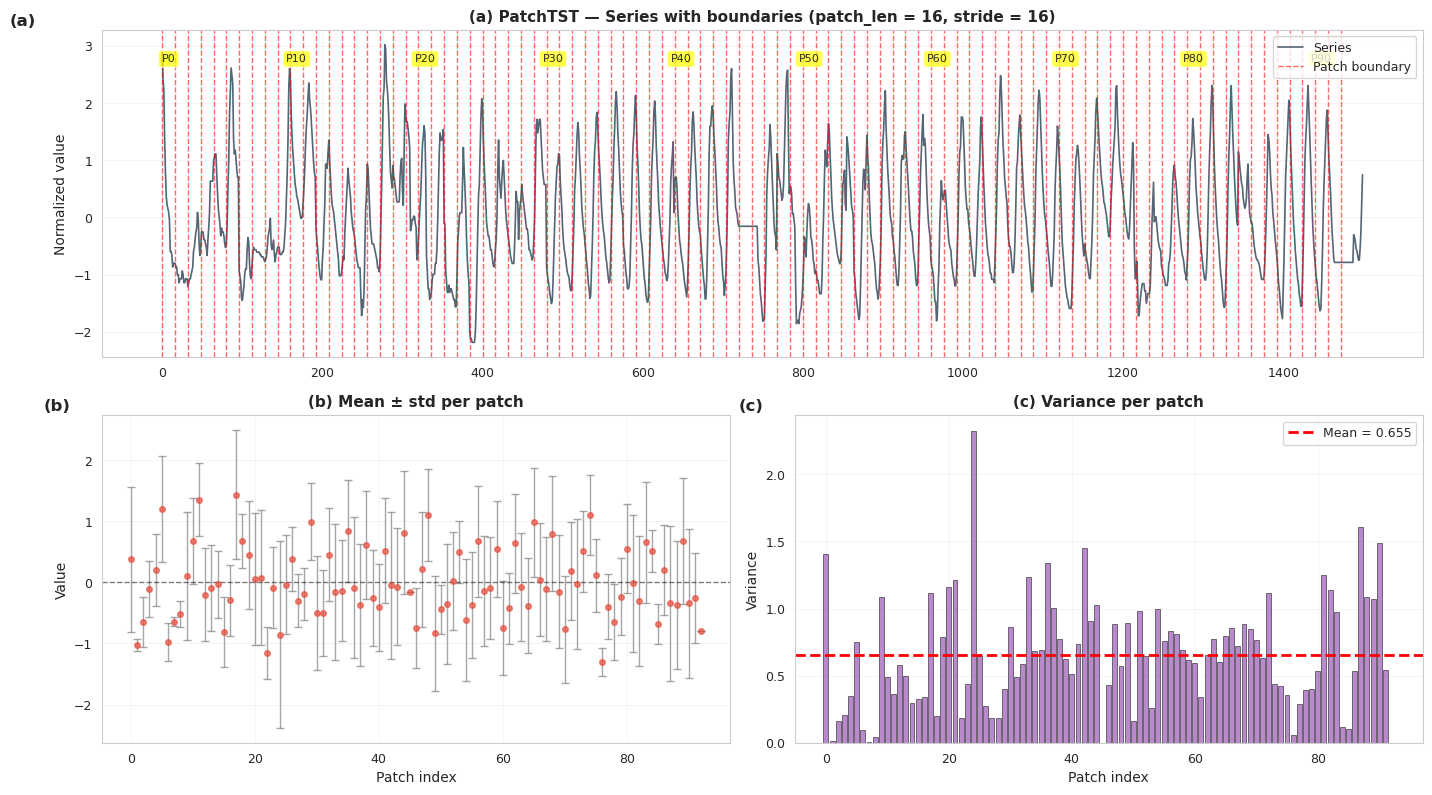

In [7]:
# === FIGURE 5 — PatchTST on ETTh2 (copia de ETTh2_tokenization cell 13) ===
patch_viz = visualize_patches(etth2_series, etth2_patch_array, 16, 16)

fig = plt.figure(figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

ax1.plot(etth2_series, linewidth=1.2, color='#2C3E50', alpha=0.8, label='Series')
label_added = False
for i, pos in enumerate(patch_viz['positions']):
    ax1.axvline(pos, color='red', linestyle='--', linewidth=1, alpha=0.6,
                label='Patch boundary' if not label_added else '')
    label_added = True
    if i % 10 == 0 and i < len(patch_viz['positions']) - 1:
        mid_pos = pos + 8
        ax1.text(mid_pos, etth2_series.max()*0.9, f'P{i}', ha='center', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax1.set_title(f'(a) PatchTST — Series with boundaries (patch_len = 16, stride = 16)',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('Normalized value', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

patch_means = etth2_patch_array.mean(axis=1)
patch_stds = etth2_patch_array.std(axis=1)
ax2.errorbar(range(len(patch_means)), patch_means, yerr=patch_stds,
             fmt='o', color='#E74C3C', ecolor='gray', alpha=0.7, capsize=3, markersize=4)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('(b) Mean ± std per patch', fontsize=11, fontweight='bold')
ax2.set_xlabel('Patch index', fontsize=10)
ax2.set_ylabel('Value', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

patch_vars = etth2_patch_array.var(axis=1)
ax3.bar(range(len(patch_vars)), patch_vars, color='#9B59B6', alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axhline(patch_vars.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {patch_vars.mean():.3f}')
ax3.set_xlabel('Patch index', fontsize=10)
ax3.set_ylabel('Variance', fontsize=10)
ax3.set_title('(c) Variance per patch', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
ax3.text(-0.05, 1.05, '(c)', transform=ax3.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
savefig_all(fig, 'fig05_patchtst_etth2')
plt.show()

  saved: fig06_autoformer_etth2.{png,pdf,svg}


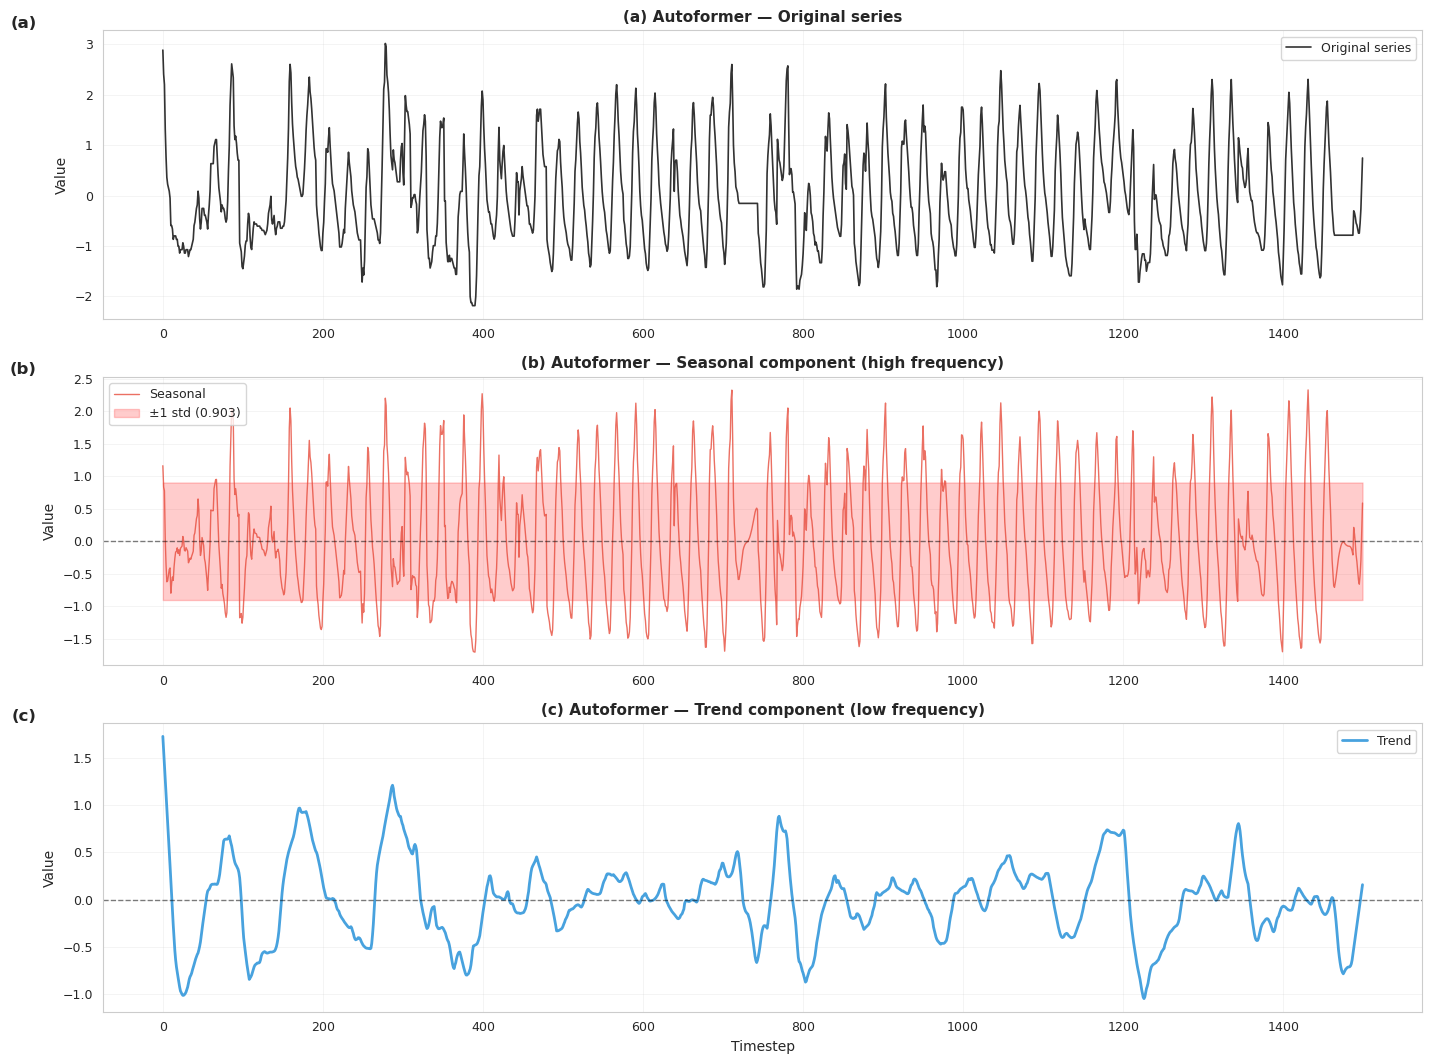

In [8]:
# === FIGURE 6 — Autoformer decomposition on ETTh2 (copia de ETTh2_tokenization cell 14) ===
decomp_viz = visualize_decomposition(etth2_decomp)

fig, axes = plt.subplots(3, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*2))

axes[0].plot(etth2_series, linewidth=1.2, color='black', alpha=0.8, label='Original series')
axes[0].set_title('(a) Autoformer — Original series', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].text(-0.05, 1.05, '(a)', transform=axes[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

axes[1].plot(etth2_decomp['seasonal'], linewidth=1, color='#E74C3C', alpha=0.8, label='Seasonal')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
seasonal_std = etth2_decomp['seasonal'].std()
axes[1].fill_between(range(len(etth2_decomp['seasonal'])), -seasonal_std, seasonal_std,
                     alpha=0.2, color='red', label=f'±1 std ({seasonal_std:.3f})')
axes[1].set_title('(b) Autoformer — Seasonal component (high frequency)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Value', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].text(-0.05, 1.05, '(b)', transform=axes[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

axes[2].plot(etth2_decomp['trend'], linewidth=2, color='#3498DB', alpha=0.9, label='Trend')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_title('(c) Autoformer — Trend component (low frequency)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Timestep', fontsize=10)
axes[2].set_ylabel('Value', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].text(-0.05, 1.05, '(c)', transform=axes[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
savefig_all(fig, 'fig06_autoformer_etth2')
plt.show()

  saved: fig07_moment_etth2.{png,pdf,svg}


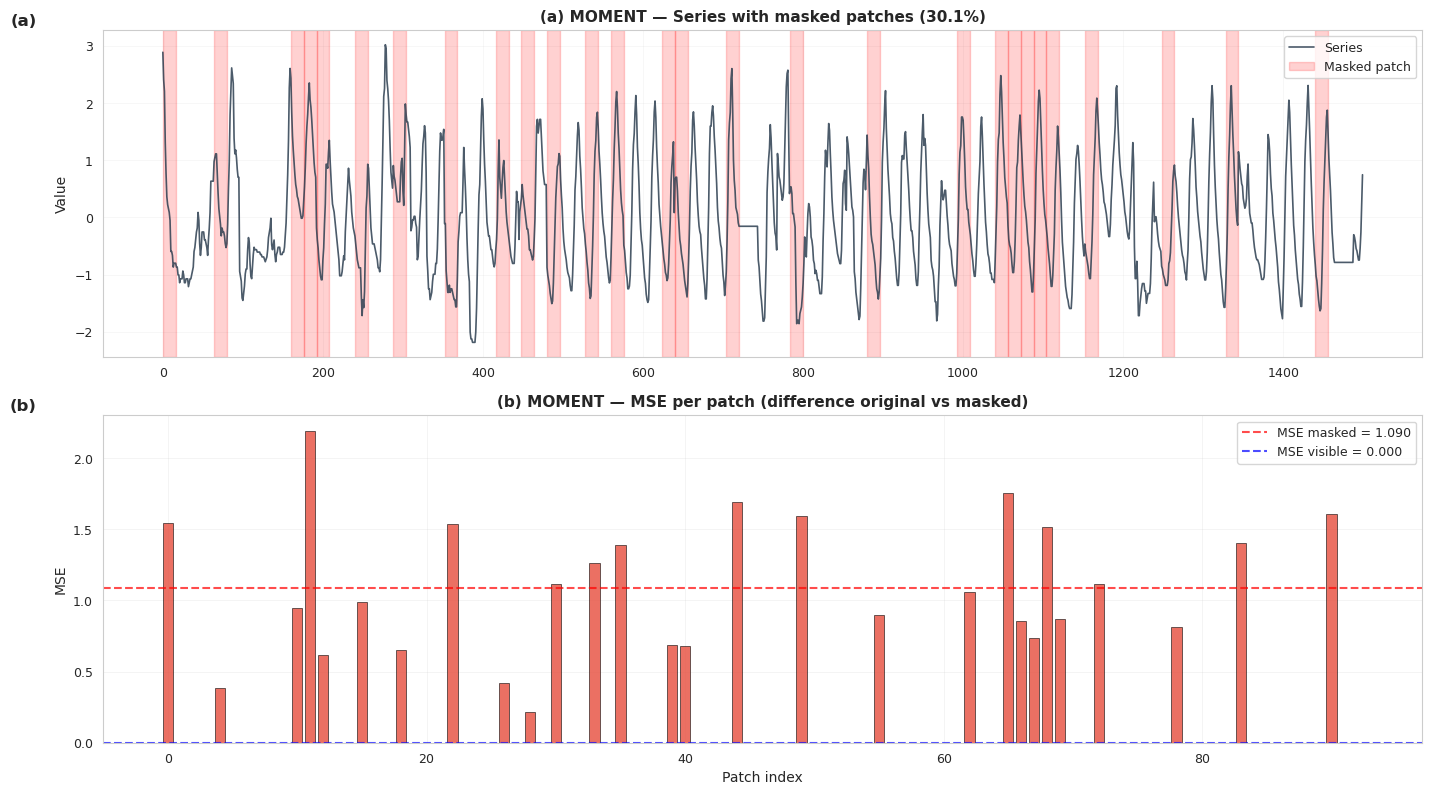

In [9]:
# === FIGURE 7 — MOMENT masked patches on ETTh2 (copia de ETTh2_tokenization cell 15) ===
found_viz = visualize_foundation(etth2_series, etth2_foundation['patches'],
                                  etth2_foundation['mask'], 16, 16)

patches = etth2_foundation['patches']
masked = etth2_foundation['mask']
masked_patches = found_viz['masked_patches']
patch_errors = np.mean((patches - masked_patches)**2, axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(FIGSIZE_DOUBLE[0]*2, FIGSIZE_DOUBLE[1]*1.5))

ax1.plot(etth2_series, linewidth=1.2, color='#2C3E50', alpha=0.85, label='Series')
label_added = False
for i, (pos, is_mask) in enumerate(zip(found_viz['patch_positions'], masked)):
    if is_mask:
        ax1.axvspan(pos, pos+16, color='red', alpha=0.18, label='Masked patch' if not label_added else '')
        label_added = True

ax1.set_title(f'(a) MOMENT — Series with masked patches ({etth2_foundation["mask_ratio_actual"]*100:.1f}%)',
             fontsize=11, fontweight='bold')
ax1.set_ylabel('Value', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.2)
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='right')

colors_mask = ['#E74C3C' if m else '#3498DB' for m in masked]
ax2.bar(range(len(patch_errors)), patch_errors, color=colors_mask, alpha=0.8, edgecolor='black', linewidth=0.5)

mse_masked = patch_errors[masked].mean() if masked.any() else 0
mse_visible = patch_errors[~masked].mean() if (~masked).any() else 0

ax2.axhline(mse_masked, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'MSE masked = {mse_masked:.3f}')
ax2.axhline(mse_visible, color='blue', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'MSE visible = {mse_visible:.3f}')

ax2.set_title('(b) MOMENT — MSE per patch (difference original vs masked)',
             fontsize=11, fontweight='bold')
ax2.set_xlabel('Patch index', fontsize=10)
ax2.set_ylabel('MSE', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
savefig_all(fig, 'fig07_moment_etth2')
plt.show()

  saved: fig14_revin_validation_etth2.{png,pdf,svg}


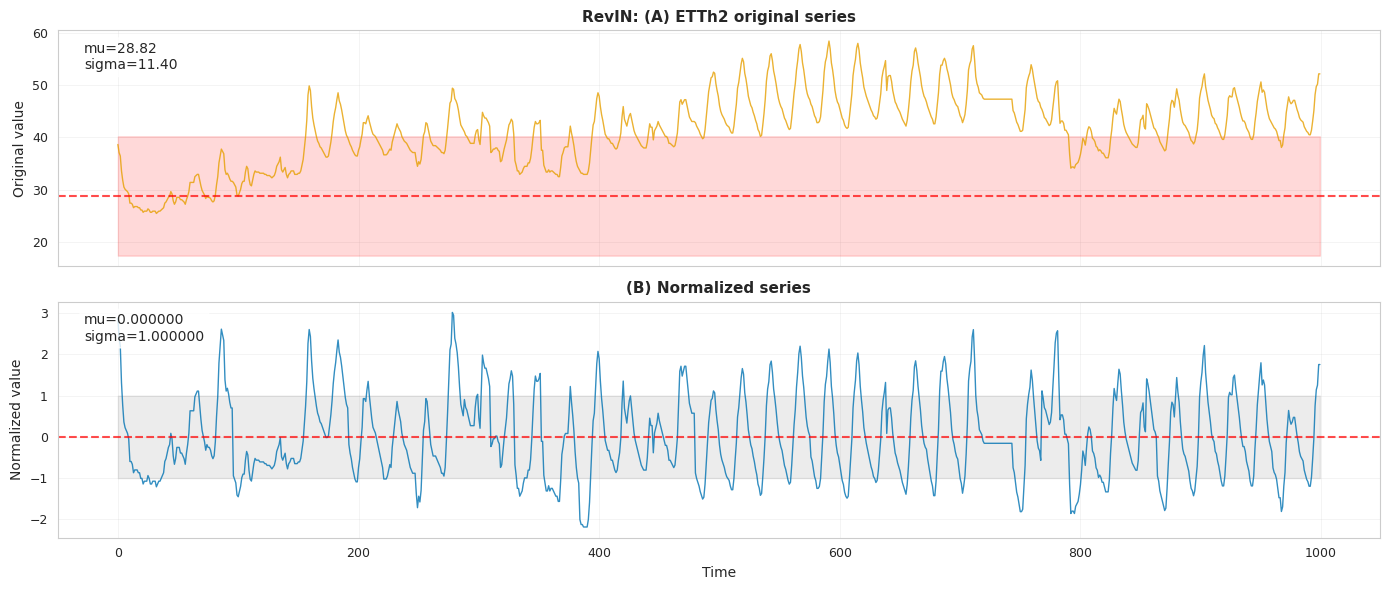

In [10]:
# === FIGURE 14 — RevIN validation on ETTh2 (copia de pipeline_RITMO_etth2 cell 2) ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
t_viz = 1000

ax1.plot(train_raw[:t_viz], color=colors_oi[0], linewidth=1, alpha=0.8)
ax1.axhline(train_raw.mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.fill_between(range(t_viz), train_raw.mean()-train_raw.std(), train_raw.mean()+train_raw.std(),
                 alpha=0.15, color='red')
ax1.text(0.02, 0.95, f'mu={train_raw.mean():.2f}\nsigma={train_raw.std():.2f}',
         transform=ax1.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax1.set_ylabel('Original value')
ax1.set_title('RevIN: (A) ETTh2 original series', fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(train_norm[:t_viz], color=colors_oi[4], linewidth=1, alpha=0.8)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.fill_between(range(t_viz), -1, 1, alpha=0.15, color='gray')
ax2.text(0.02, 0.95, f'mu={train_norm.mean():.6f}\nsigma={train_norm.std():.6f}',
         transform=ax2.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.set_ylabel('Normalized value')
ax2.set_xlabel('Time')
ax2.set_title('(B) Normalized series', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
savefig_all(fig, 'fig14_revin_validation_etth2')
plt.show()

[Re-running Baum-Welch on ETTh2 K=5 to capture convergence curve...]
  saved: fig15_baumwelch_convergence_etth2_K5.{png,pdf,svg}


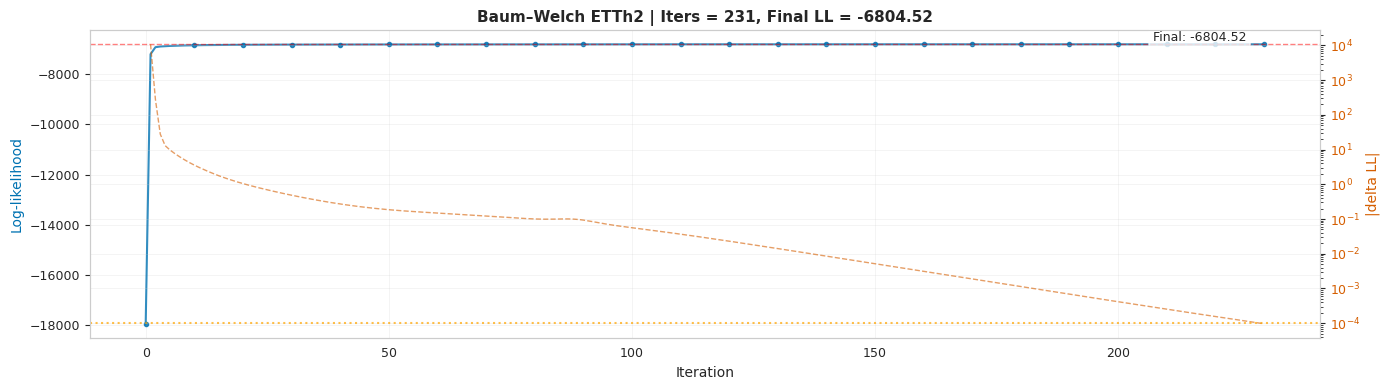

In [11]:
# === FIGURE 15 — Baum-Welch convergence ETTh2 K=5 (copia de pipeline_RITMO_etth2 cell 4) ===
# Re-run Baum-Welch to capture log_likelihoods (cache may not store them)
from hmm.baum_welch import baum_welch
print('[Re-running Baum-Welch on ETTh2 K=5 to capture convergence curve...]')
result_bw = baum_welch(
    observations=train_norm, K=K_SELECTED,
    max_iter=500, epsilon=1e-4, random_state=42, verbose=False,
)
A_bw, pi_bw, mu_bw, sigma_bw = result_bw['A'], result_bw['pi'], result_bw['mu'], result_bw['sigma']
log_likelihoods = result_bw.get('log_likelihoods', [])

if len(log_likelihoods) > 1:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(log_likelihoods, color=colors_oi[4], linewidth=1.5, marker='o',
            markersize=3, markevery=10, alpha=0.8)
    ax.axhline(log_likelihoods[-1], color='red', linestyle='--', alpha=0.5)
    ax.text(len(log_likelihoods)*0.98, log_likelihoods[-1],
            f'Final: {log_likelihoods[-1]:.2f}', ha='right', va='bottom',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax2 = ax.twinx()
    deltas = np.abs(np.diff(log_likelihoods))
    ax2.plot(range(1, len(deltas)+1), deltas, color=colors_oi[5], linewidth=1, alpha=0.6, linestyle='--')
    ax2.axhline(1e-4, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.set_ylabel('|delta LL|', color=colors_oi[5])
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor=colors_oi[5])

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-likelihood', color=colors_oi[4])
    ax.set_title(f'Baum–Welch ETTh2 | Iters = {len(log_likelihoods)}, Final LL = {log_likelihoods[-1]:.2f}',
                 fontweight='bold')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    savefig_all(fig, 'fig15_baumwelch_convergence_etth2_K5')
    plt.show()

  saved: fig16_viterbi_etth2_K5.{png,pdf,svg}


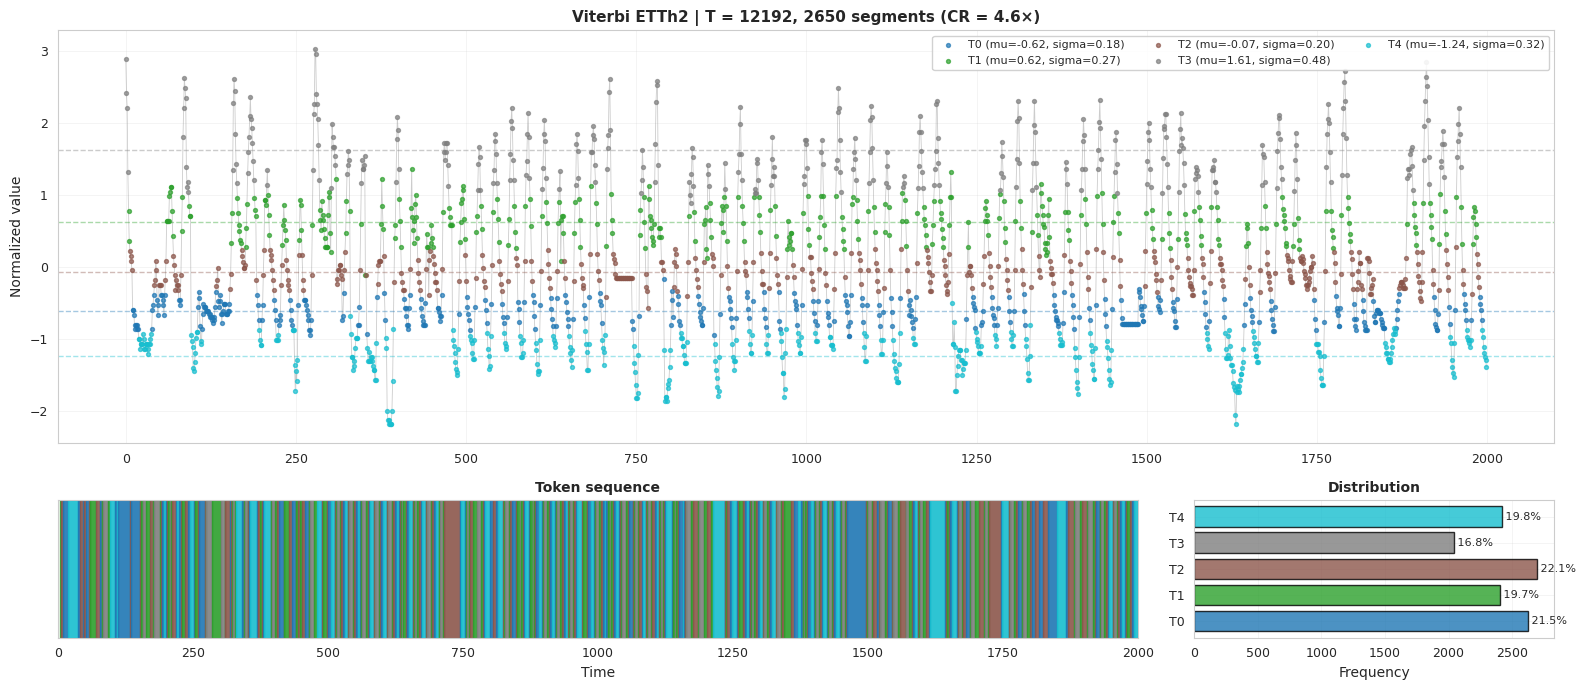

In [12]:
# === FIGURE 16 — Viterbi tokenization ETTh2 K=5 (copia de pipeline_RITMO_etth2 cell 6) ===
states_v = states  # already computed in setup
state_changes = np.sum(states_v[1:] != states_v[:-1])
compression_ratio = len(train_norm) / (state_changes + 1)

fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], width_ratios=[3, 1])
ax_series = fig.add_subplot(gs[0, :])
ax_bar = fig.add_subplot(gs[1, 0])
ax_stats = fig.add_subplot(gs[1, 1])

t_viz = 2000
colors_tokens = plt.cm.tab10(np.linspace(0, 1, K_SELECTED))

ax_series.plot(train_norm[:t_viz], color='gray', linewidth=0.6, alpha=0.4, zorder=1)
mu_arr = etth2_params['mu']; sigma_arr = etth2_params['sigma']
for k in range(K_SELECTED):
    mask = states_v[:t_viz] == k
    if np.any(mask):
        ax_series.scatter(np.where(mask)[0], train_norm[:t_viz][mask],
                          color=colors_tokens[k], s=8, alpha=0.7,
                          label=f'T{k} (mu={mu_arr[k]:.2f}, sigma={sigma_arr[k]:.2f})', zorder=2)
        ax_series.axhline(mu_arr[k], color=colors_tokens[k], linestyle='--', linewidth=1, alpha=0.4)

ax_series.set_ylabel('Normalized value')
ax_series.set_title(f'Viterbi ETTh2 | T = {len(states_v)}, {state_changes+1} segments (CR = {compression_ratio:.1f}×)',
                    fontweight='bold')
ax_series.legend(loc='upper right', fontsize=8, ncol=3, framealpha=0.9)
ax_series.grid(alpha=0.3)

segment_starts = np.where(np.diff(np.concatenate([[states_v[0]], states_v[:t_viz]])) != 0)[0]
segment_starts = np.concatenate([segment_starts, [t_viz]])
for i in range(len(segment_starts)-1):
    start = segment_starts[i]
    end = segment_starts[i+1]
    ax_bar.axvspan(start, end, color=colors_tokens[states_v[start]], alpha=0.9)

ax_bar.set_xlim(0, t_viz)
ax_bar.set_yticks([])
ax_bar.set_xlabel('Time')
ax_bar.set_title('Token sequence', fontweight='bold', fontsize=10)

token_counts = [np.sum(states_v == k) for k in range(K_SELECTED)]
ax_stats.barh(range(K_SELECTED), token_counts, color=colors_tokens, alpha=0.8, edgecolor='black')
ax_stats.set_yticks(range(K_SELECTED))
ax_stats.set_yticklabels([f'T{k}' for k in range(K_SELECTED)])
ax_stats.set_xlabel('Frequency')
ax_stats.set_title('Distribution', fontweight='bold', fontsize=10)
ax_stats.grid(alpha=0.3, axis='x')
for k in range(K_SELECTED):
    pct = 100 * token_counts[k] / len(states_v)
    ax_stats.text(token_counts[k], k, f' {pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
savefig_all(fig, 'fig16_viterbi_etth2_K5')
plt.show()

  saved: fig17_embedding_transition_etth2_K5.{png,pdf,svg}


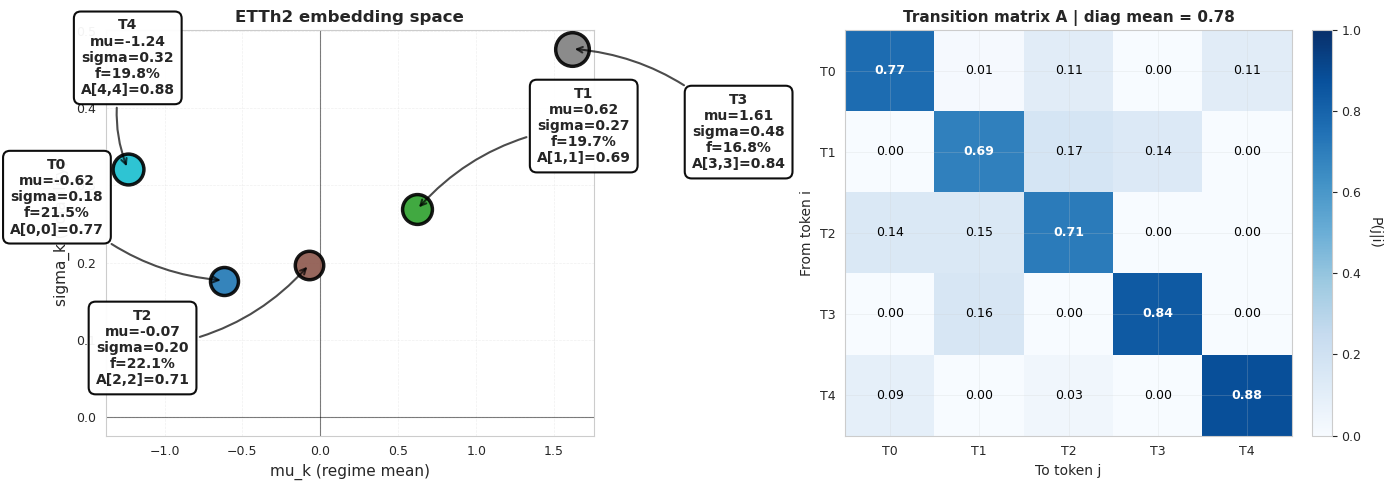

In [13]:
# === FIGURE 17 — μ-σ space + Transition matrix ETTh2 K=5 (copia de pipeline_RITMO_etth2 cell 7) ===
A_e = etth2_params['A']; mu_e = etth2_params['mu']; sigma_e = etth2_params['sigma']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

offsets = [(-120, 60), (120, 60), (-120, -60), (120, -60), (0, 80)]
for k in range(K_SELECTED):
    size = 300 + sigma_e[k] * 600
    ax1.scatter(mu_e[k], sigma_e[k], c=[colors_tokens[k]], s=size,
                edgecolors='black', linewidths=2.5, zorder=3, alpha=0.9)
    freq_pct = 100 * np.sum(states_v == k) / len(states_v)
    ax1.annotate(f'T{k}\nmu={mu_e[k]:.2f}\nsigma={sigma_e[k]:.2f}\nf={freq_pct:.1f}%\nA[{k},{k}]={A_e[k,k]:.2f}',
                xy=(mu_e[k], sigma_e[k]), xytext=offsets[k % len(offsets)], textcoords='offset points',
                fontsize=10, ha='center', va='center', fontweight='bold', zorder=5,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.95, linewidth=1.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='black', lw=1.5, alpha=0.7))

ax1.set_xlabel('mu_k (regime mean)', fontsize=11)
ax1.set_ylabel('sigma_k (volatility)', fontsize=11)
ax1.set_title('ETTh2 embedding space', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3, linestyle='--')
ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.8, alpha=0.5)

im = ax2.imshow(A_e, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax2.set_xlabel('To token j')
ax2.set_ylabel('From token i')
ax2.set_title(f'Transition matrix A | diag mean = {np.diag(A_e).mean():.2f}', fontweight='bold')
ax2.set_xticks(range(K_SELECTED))
ax2.set_yticks(range(K_SELECTED))
ax2.set_xticklabels([f'T{k}' for k in range(K_SELECTED)])
ax2.set_yticklabels([f'T{k}' for k in range(K_SELECTED)])
for i in range(K_SELECTED):
    for j in range(K_SELECTED):
        ax2.text(j, i, f'{A_e[i,j]:.2f}', ha='center', va='center',
                color='white' if A_e[i,j] > 0.5 else 'black',
                fontsize=9, fontweight='bold' if i==j else 'normal')

cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('P(j|i)', rotation=270, labelpad=15)

plt.tight_layout()
savefig_all(fig, 'fig17_embedding_transition_etth2_K5')
plt.show()

In [14]:
# === DATA LOAD for F18, F19 — 3-seed final_paper1 results (288 runs) ===
# Patrón: results/plan_a_*final_paper1_{tech}[_K{K}]_seed{s}_0/metrics.npy
PRED_LENS = [96, 192, 336, 720]
DS_ORDER = ['ETTh1', 'ETTh2', 'Weather', 'custom']
DS_LABELS = {'ETTh1': 'ETTh1', 'ETTh2': 'ETTh2', 'Weather': 'Weather', 'custom': 'Electricity'}

# K-optimal robust per dataset (paper §4.3, Table 2)
RITMO_BEST = {
    'ETTh1':   'hmm_soft_K8',
    'ETTh2':   'hmm_soft_K9',
    'Weather': 'hmm_soft_residual_K4',
    'custom':  'hmm_soft_residual_K3',
}
BASELINES = ['patching', 'decomposition', 'foundation', 'text_based', 'discretization']
COL_ORDER = ['RITMO'] + BASELINES

COL_NAMES = {
    'RITMO': 'RITMO (Ours)',
    'patching': 'Patching',
    'decomposition': 'Decomposition',
    'foundation': 'Foundation',
    'text_based': 'Text-based',
    'discretization': 'Discretization',
}
COL_COLORS = {
    'RITMO': colors_oi[5],
    'patching': colors_oi[1],
    'decomposition': colors_oi[2],
    'foundation': colors_oi[4],
    'text_based': colors_oi[6],
    'discretization': colors_oi[7],
}

# Cargar 288 runs y agregar mean ± std sobre 3 seeds
rows = []
results_dir = REPO / 'results'
pat = re.compile(r'plan_a_(\w+?)_96_(\d+)_TransformerCommon_.+_final_paper1_(.+?)_seed(\d+)_0$')
for d in os.listdir(results_dir):
    m = pat.match(d)
    if not m: continue
    mpath = results_dir / d / 'metrics.npy'
    if not mpath.exists(): continue
    metrics = np.load(mpath)
    rows.append((m.group(1), m.group(3), int(m.group(2)), int(m.group(4)),
                 float(metrics[1]), float(metrics[0])))  # ds, tech, pl, seed, mse, mae

# Aggregate
data_3seed = defaultdict(lambda: defaultdict(dict))
seed_data = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for ds, tech, pl, seed, mse, mae in rows:
    seed_data[ds][tech][pl].append((mse, mae))

for ds in seed_data:
    for tech in seed_data[ds]:
        for pl in seed_data[ds][tech]:
            mses = [x[0] for x in seed_data[ds][tech][pl]]
            maes = [x[1] for x in seed_data[ds][tech][pl]]
            data_3seed[ds][tech][pl] = (np.mean(mses), np.std(mses), np.mean(maes), np.std(maes))

# Merge RITMO variants per dataset
data = defaultdict(lambda: defaultdict(dict))
for ds in DS_ORDER:
    ritmo_key = RITMO_BEST[ds]
    if ritmo_key in data_3seed[ds]:
        for pl in PRED_LENS:
            v = data_3seed[ds][ritmo_key].get(pl)
            if v: data[ds]['RITMO'][pl] = v
    for b in BASELINES:
        if b in data_3seed[ds]:
            for pl in PRED_LENS:
                v = data_3seed[ds][b].get(pl)
                if v: data[ds][b][pl] = v

print(f'[3-seed data] Loaded {len(rows)} runs across {len(data_3seed)} datasets')
for ds in DS_ORDER:
    avg = np.mean([data[ds]['RITMO'].get(pl, (999,))[0] for pl in PRED_LENS])
    print(f'  {DS_LABELS[ds]}: RITMO={RITMO_BEST[ds]}, avg MSE={avg:.6f}')

[3-seed data] Loaded 288 runs across 4 datasets
  ETTh1: RITMO=hmm_soft_K8, avg MSE=0.082438
  ETTh2: RITMO=hmm_soft_K9, avg MSE=0.201542
  Weather: RITMO=hmm_soft_residual_K4, avg MSE=0.001633
  Electricity: RITMO=hmm_soft_residual_K3, avg MSE=0.369111


  saved: fig18_plan_a_mse_per_horizon_3seeds.{png,pdf,svg}


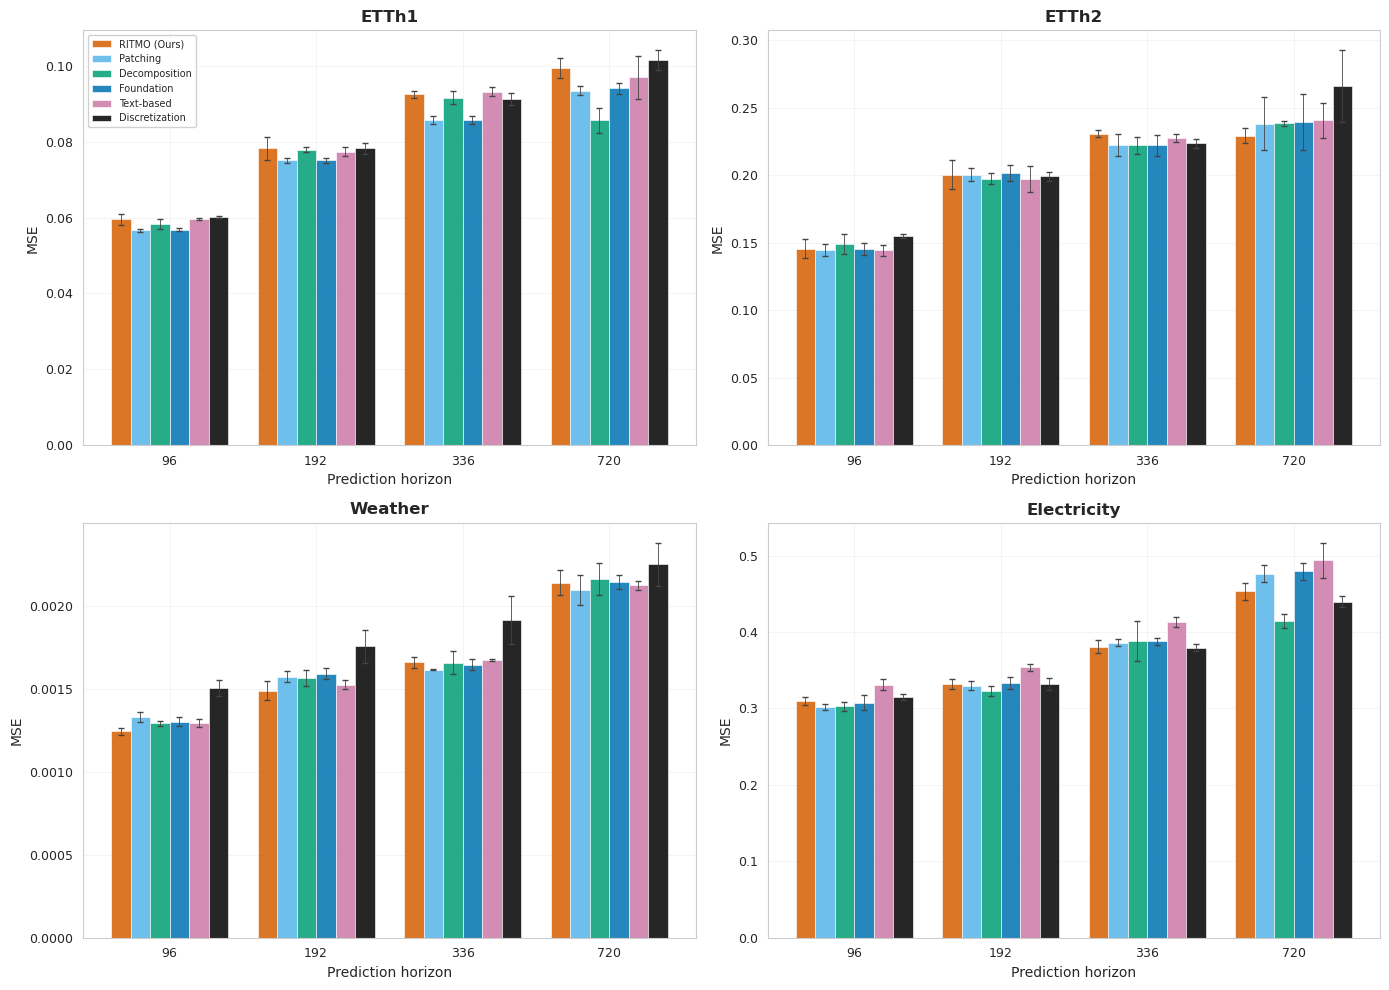

In [15]:
# === FIGURE 18 — Plan A MSE per technique × horizon (copia de visualizations cell 3, 3-seed) ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, ds in enumerate(DS_ORDER):
    ax = axes[idx]
    ds_label = DS_LABELS[ds]
    n_techs = len(COL_ORDER)
    x = np.arange(len(PRED_LENS))
    width = 0.8 / n_techs

    for i, t in enumerate(COL_ORDER):
        means = [data[ds][t].get(pl, (float('nan'),))[0] for pl in PRED_LENS]
        stds  = [data[ds][t].get(pl, (np.nan, np.nan))[1] for pl in PRED_LENS]
        ax.bar(x + i * width - 0.4 + width/2, means, width,
               yerr=stds, capsize=2,
               label=COL_NAMES[t], color=COL_COLORS[t], alpha=0.85,
               edgecolor='white', linewidth=0.5,
               error_kw={'linewidth': 0.6, 'ecolor': '#444'})

    ax.set_xticks(x)
    ax.set_xticklabels([str(pl) for pl in PRED_LENS])
    ax.set_xlabel('Prediction horizon', fontsize=10)
    ax.set_ylabel('MSE', fontsize=10)
    ax.set_title(ds_label, fontweight='bold', fontsize=12)

axes[0].legend(fontsize=7, loc='upper left', framealpha=0.9)
plt.tight_layout()
savefig_all(fig, 'fig18_plan_a_mse_per_horizon_3seeds')
plt.show()

  saved: fig19_ranking_heatmap_3seeds.{png,pdf,svg}


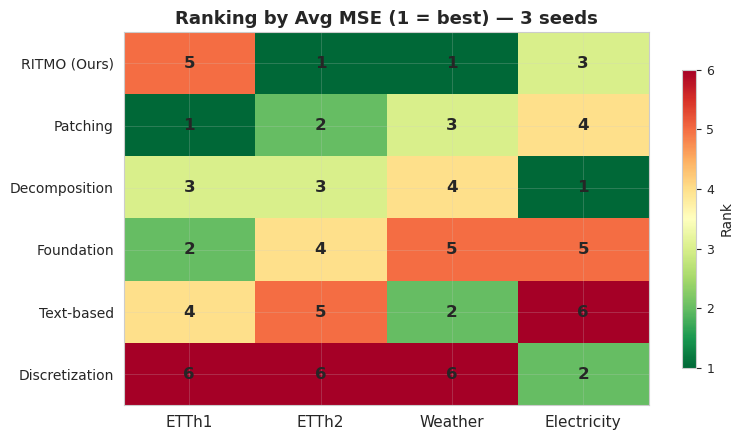

In [16]:
# === FIGURE 19 — Ranking heatmap 6×4 (copia de visualizations cell 4, 3-seed) ===
rank_matrix = np.zeros((len(COL_ORDER), len(DS_ORDER)))
for j, ds in enumerate(DS_ORDER):
    avgs = [(t, np.mean([data[ds][t].get(pl, (999,))[0] for pl in PRED_LENS]))
            for t in COL_ORDER]
    avgs_sorted = sorted(avgs, key=lambda x: x[1])
    for rank, (t, _) in enumerate(avgs_sorted, 1):
        i = COL_ORDER.index(t)
        rank_matrix[i, j] = rank

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(rank_matrix, cmap='RdYlGn_r', aspect='auto',
               vmin=1, vmax=len(COL_ORDER))
ax.set_xticks(range(len(DS_ORDER)))
ax.set_xticklabels([DS_LABELS[ds] for ds in DS_ORDER], fontsize=11)
ax.set_yticks(range(len(COL_ORDER)))
ax.set_yticklabels([COL_NAMES[t] for t in COL_ORDER], fontsize=10)

for i in range(len(COL_ORDER)):
    for j in range(len(DS_ORDER)):
        ax.text(j, i, f"{int(rank_matrix[i,j])}", ha='center', va='center',
                fontsize=12, fontweight='bold')

ax.set_title('Ranking by Avg MSE (1 = best) — 3 seeds', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, label='Rank', shrink=0.8)
plt.tight_layout()
savefig_all(fig, 'fig19_ranking_heatmap_3seeds')
plt.show()

In [17]:
# === DATA LOAD for F20-F22 — Weather K=4 cache (copia de visualizations cell 5-6) ===
from hmm import forward_backward_batch

# Load Weather K=4 cache (paper-optimal robust)
cache_w = torch.load(REPO / 'cache/hmm_weather_K4.pth', weights_only=False)
A = cache_w['A'].numpy() if isinstance(cache_w['A'], torch.Tensor) else cache_w['A']
pi = cache_w['pi'].numpy() if isinstance(cache_w['pi'], torch.Tensor) else cache_w['pi']
mu = cache_w['mu'].numpy() if isinstance(cache_w['mu'], torch.Tensor) else cache_w['mu']
sigma = cache_w['sigma'].numpy() if isinstance(cache_w['sigma'], torch.Tensor) else cache_w['sigma']
K = len(mu)
print(f'[CACHE HMM Weather] K={K} states loaded')
print(f'  mu: {np.round(mu, 4)}')
print(f'  sigma: {np.round(sigma, 4)}')

# Load Weather data with same RevIN per-window as pipeline
df_w = pd.read_csv(REPO / 'dataset/weather/weather.csv')
values = df_w['OT'].values.astype(float)
seq_len = 96
n_train_w = int(len(values) * 0.7)
train_raw_w = values[:n_train_w]

# Take test segment and normalize per-window too
test_start = int(len(values) * 0.8)
test_raw = values[test_start:]
test_windows = []
for start in range(0, len(test_raw) - seq_len + 1, seq_len):
    w = test_raw[start:start + seq_len]
    w_mean, w_std = w.mean(), max(w.std(), 1e-5)
    test_windows.append((w - w_mean) / w_std)
segment = np.concatenate(test_windows[:20])  # 20 windows = 1920 timesteps

print(f'Segment: {len(segment)} timesteps, range [{segment.min():.2f}, {segment.max():.2f}]')

# Forward-backward to get gamma
gamma, _, _ = forward_backward_batch(
    segment.reshape(1, -1), A, pi, mu, sigma, need_xi=False
)
gamma = gamma[0]  # [T, K]
states_w = np.argmax(gamma, axis=1)

# Sort states by mu
state_order = np.argsort(mu)
state_map = {old: new for new, old in enumerate(state_order)}
states_mapped = np.array([state_map[s] for s in states_w])
mu_sorted = mu[state_order]
sigma_sorted = sigma[state_order]

colors_tokens_w = [plt.cm.tab10(i) for i in range(K)]
state_colors_w = colors_tokens_w

[CACHE HMM Weather] K=4 states loaded
  mu: [-1.2164  0.038  -0.6747  1.1959]
  sigma: [0.267  0.2819 0.163  0.5672]
Segment: 1920 timesteps, range [-2.74, 3.44]


  saved: fig20_hmm_weather_K4_tokens.{png,pdf,svg}


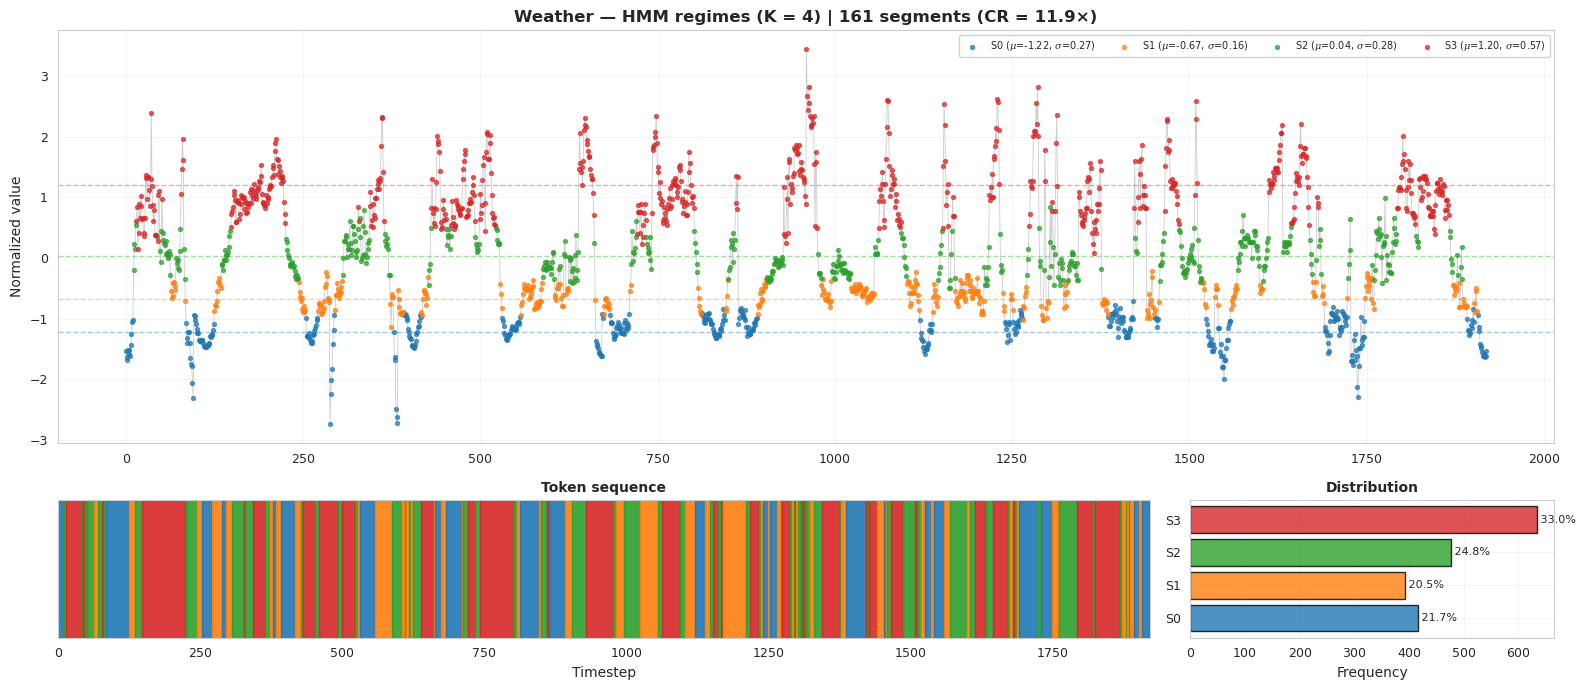

In [18]:
# === FIGURE 20 — Weather K=4 regimes + token bar + frequency (copia de visualizations cell 6) ===
t_viz_w = len(segment)
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], width_ratios=[3, 1])
ax_series = fig.add_subplot(gs[0, :])
ax_bar = fig.add_subplot(gs[1, 0])
ax_stats = fig.add_subplot(gs[1, 1])

ax_series.plot(segment[:t_viz_w], color='gray', linewidth=0.6, alpha=0.4, zorder=1)
for k in range(K):
    mask = states_mapped[:t_viz_w] == k
    if np.any(mask):
        ax_series.scatter(
            np.where(mask)[0], segment[:t_viz_w][mask],
            color=colors_tokens_w[k], s=8, alpha=0.7, zorder=2,
            label=f'S{k} ($\\mu$={mu_sorted[k]:.2f}, $\\sigma$={sigma_sorted[k]:.2f})'
        )
        ax_series.axhline(mu_sorted[k], color=colors_tokens_w[k], linestyle='--',
                          linewidth=1, alpha=0.4)

ax_series.set_ylabel('Normalized value')
state_changes_w = np.sum(states_mapped[1:] != states_mapped[:-1])
cr = len(segment) / (state_changes_w + 1)
ax_series.set_title(f'Weather — HMM regimes (K = {K}) | {state_changes_w+1} segments (CR = {cr:.1f}×)',
                    fontweight='bold', fontsize=12)
ax_series.legend(loc='upper right', fontsize=7, ncol=4, framealpha=0.9)
ax_series.grid(alpha=0.3)

prev = states_mapped[0]
start = 0
for t in range(1, min(t_viz_w, len(states_mapped))):
    if states_mapped[t] != prev or t == min(t_viz_w, len(states_mapped)) - 1:
        ax_bar.axvspan(start, t, color=colors_tokens_w[prev], alpha=0.9)
        start = t
        prev = states_mapped[t]
ax_bar.set_xlim(0, t_viz_w)
ax_bar.set_yticks([])
ax_bar.set_xlabel('Timestep')
ax_bar.set_title('Token sequence', fontweight='bold', fontsize=10)

token_counts_w = [np.sum(states_mapped == k) for k in range(K)]
ax_stats.barh(range(K), token_counts_w, color=colors_tokens_w, alpha=0.8, edgecolor='black')
ax_stats.set_yticks(range(K))
ax_stats.set_yticklabels([f'S{k}' for k in range(K)])
ax_stats.set_xlabel('Frequency')
ax_stats.set_title('Distribution', fontweight='bold', fontsize=10)
ax_stats.grid(alpha=0.3, axis='x')
for k in range(K):
    pct = 100 * token_counts_w[k] / len(states_mapped)
    ax_stats.text(token_counts_w[k], k, f' {pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
savefig_all(fig, 'fig20_hmm_weather_K4_tokens')
plt.show()

  saved: fig21_transition_weather_K4.{png,pdf,svg}


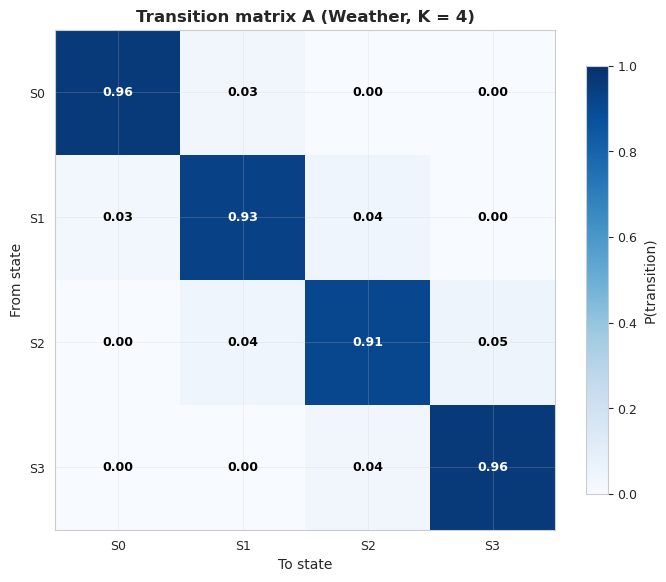

In [19]:
# === FIGURE 21 — Transition matrix Weather K=4 (copia de visualizations cell 7) ===
fig, ax = plt.subplots(figsize=(7, 6))
A_sorted = A[state_order][:, state_order]
im = ax.imshow(A_sorted, cmap='Blues', vmin=0, vmax=1)
for i in range(K):
    for j in range(K):
        val = A_sorted[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                color=color, fontweight='bold')

ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels([f'S{i}' for i in range(K)])
ax.set_yticklabels([f'S{i}' for i in range(K)])
ax.set_xlabel('To state', fontsize=10)
ax.set_ylabel('From state', fontsize=10)
ax.set_title(f'Transition matrix A (Weather, K = {K})', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='P(transition)', shrink=0.8)
plt.tight_layout()
savefig_all(fig, 'fig21_transition_weather_K4')
plt.show()

  saved: fig22_embedding_weather_K4.{png,pdf,svg}


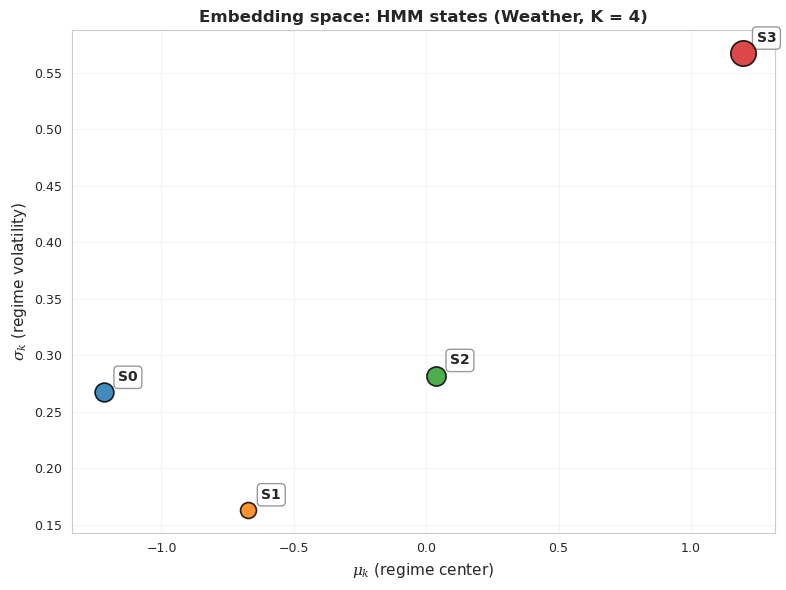

In [20]:
# === FIGURE 22 — Embedding space μ-σ Weather K=4 (copia de visualizations cell 8) ===
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(K):
    size = sigma_sorted[i] * 500 + 50
    ax.scatter(mu_sorted[i], sigma_sorted[i], s=size, c=[state_colors_w[i]],
               edgecolors='black', linewidth=1.2, zorder=5, alpha=0.85)
    ax.annotate(f'S{i}', (mu_sorted[i], sigma_sorted[i]),
                textcoords='offset points', xytext=(10, 8),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='gray', alpha=0.8))

ax.set_xlabel(r'$\mu_k$ (regime center)', fontsize=11)
ax.set_ylabel(r'$\sigma_k$ (regime volatility)', fontsize=11)
ax.set_title(f'Embedding space: HMM states (Weather, K = {K})', fontweight='bold', fontsize=12)
plt.tight_layout()
savefig_all(fig, 'fig22_embedding_weather_K4')
plt.show()

In [21]:
# === SUMMARY ===
files = sorted(os.listdir(OUT_DIR))
png_count = sum(1 for f in files if f.endswith('.png'))
pdf_count = sum(1 for f in files if f.endswith('.pdf'))
svg_count = sum(1 for f in files if f.endswith('.svg'))
print(f'\n[OK] Figure generation complete.')
print(f'  Output: {OUT_DIR}')
print(f'  Files: {png_count} png, {pdf_count} pdf, {svg_count} svg')


[OK] Figure generation complete.
  Output: /home/jaime/TFG/RITMO/memoria/secciones/figures_paper1
  Files: 32 png, 32 pdf, 24 svg
